## Titanic Survival Prediction
This notebook uses the Titanic dataset to predict whether a passenger survived or not.


In [92]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


from xgboost import XGBClassifier

## Import and Load Data
I loaded the dataset and started by looking at the first rows.


In [93]:
df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Basic Data Checks
I checked the shape, data types, summary statistics, missing values, and duplicates.


In [94]:
df.shape

(891, 12)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [96]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [97]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [98]:
df.duplicated().sum()

np.int64(0)

## Target Distribution
I checked the `Survived` column to see the balance between survived and not survived passengers.


Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


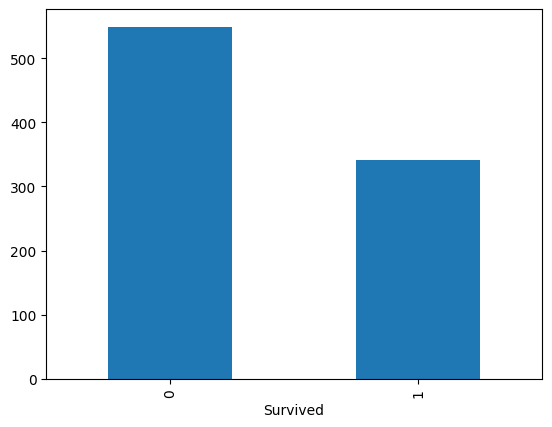

In [99]:
df["Survived"].value_counts().plot(kind="bar")
print(df["Survived"].value_counts(dropna=False))
print(df["Survived"].value_counts(normalize=True))

## Simple EDA
I used basic plots to understand the main columns before cleaning and modeling.


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

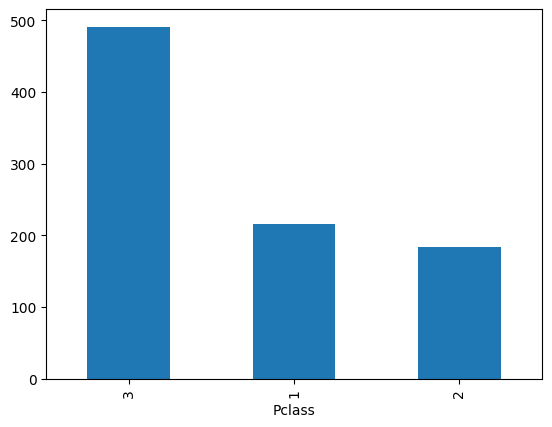

In [100]:
df["Pclass"].value_counts().plot(kind="bar")
df["Pclass"].value_counts(dropna=False)

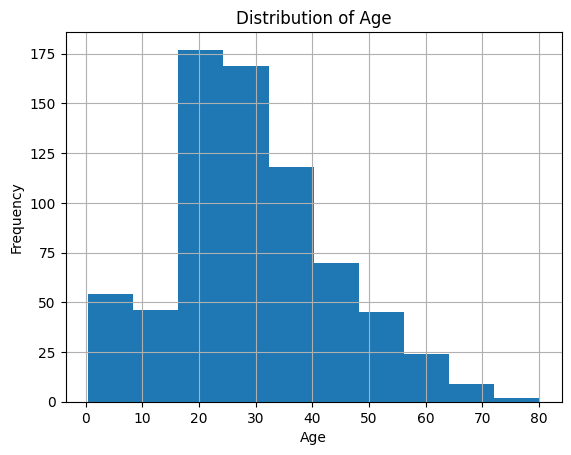

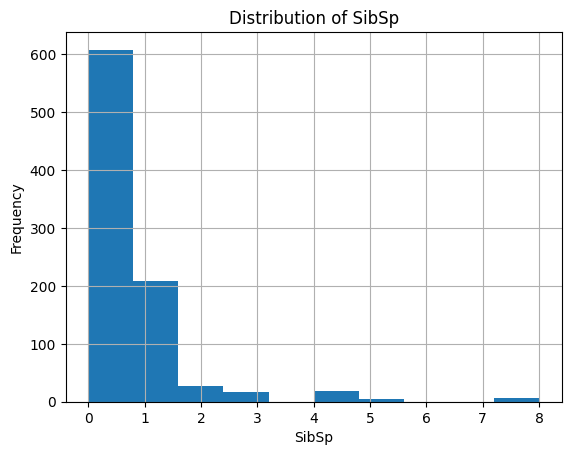

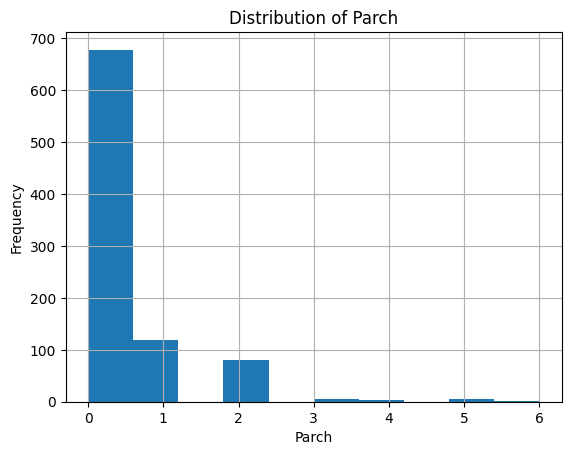

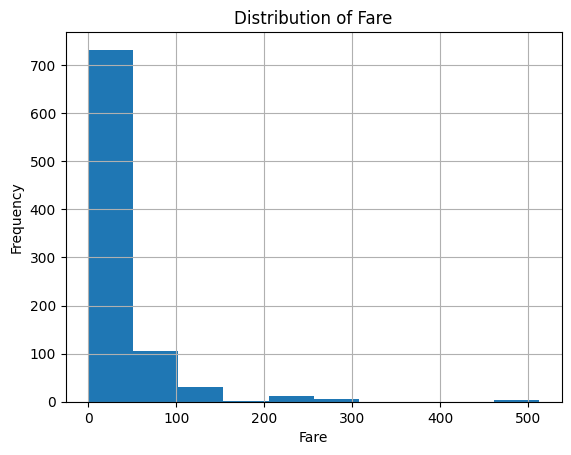

In [101]:
df["Age"].hist()
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

df["SibSp"].hist()
plt.title("Distribution of SibSp")
plt.xlabel("SibSp")
plt.ylabel("Frequency")
plt.show()

df["Parch"].hist()
plt.title("Distribution of Parch")
plt.xlabel("Parch")
plt.ylabel("Frequency")
plt.show()

df["Fare"].hist()
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

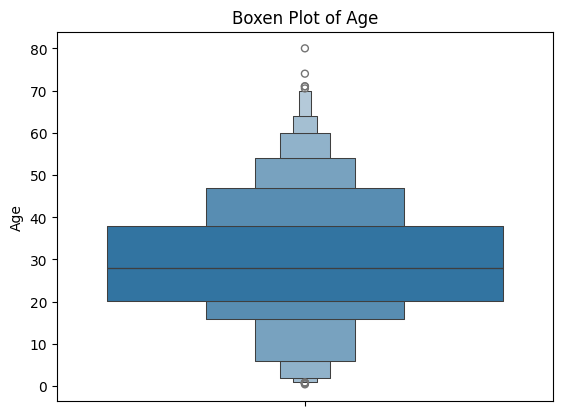

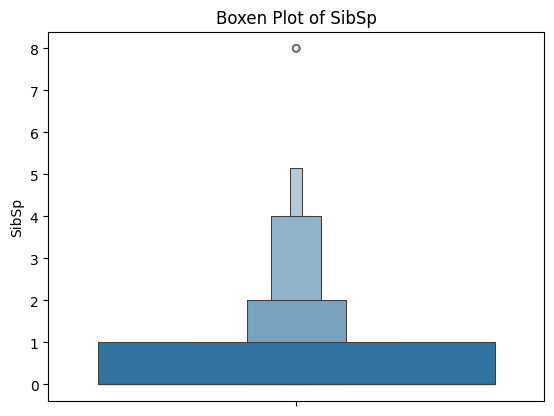

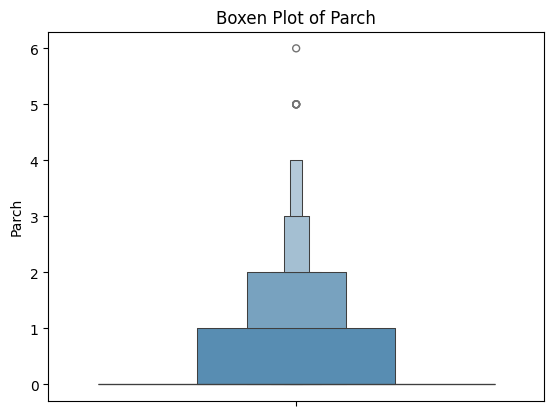

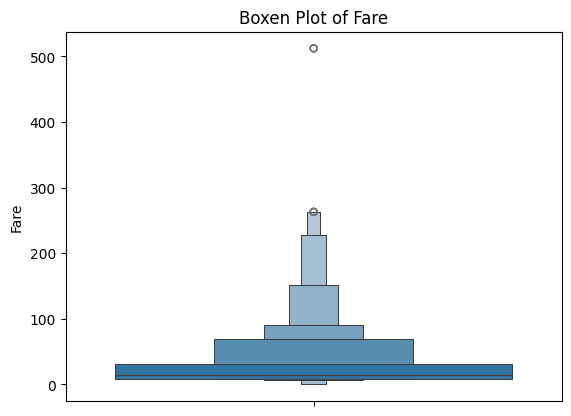

In [102]:
sns.boxenplot(y=df["Age"])
plt.title("Boxen Plot of Age")
plt.show()

sns.boxenplot(y=df["SibSp"])
plt.title("Boxen Plot of SibSp")
plt.show()

sns.boxenplot(y=df["Parch"])
plt.title("Boxen Plot of Parch")
plt.show()

sns.boxenplot(y=df["Fare"])
plt.title("Boxen Plot of Fare")
plt.show()


## Handling Missing Age
Age has missing values, so I checked the median age for each `Pclass` and `Sex` group.


In [103]:
df.groupby(["Pclass", "Sex"])["Age"].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [104]:
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
df["Age"].isnull().sum()

np.int64(0)

## Handling Missing Embarked
`Embarked` is a categorical column, so I filled its missing values using the mode.


In [105]:
print(df["Embarked"].value_counts(dropna=False))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


## Cabin Feature
Instead of dropping `Cabin` directly, I created `HasCabin` to keep whether the passenger had a cabin recorded.


HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


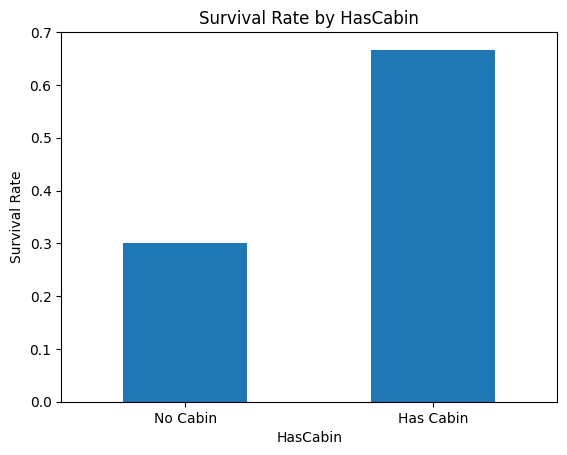

In [106]:
df["HasCabin"] = df["Cabin"].notnull().astype(int)

print(df.groupby("HasCabin")["Survived"].mean())

df.groupby("HasCabin")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by HasCabin")
plt.xlabel("HasCabin")
plt.ylabel("Survival Rate")
plt.xticks(ticks=[0, 1], labels=["No Cabin", "Has Cabin"], rotation=0)
plt.show()

In [107]:
df["HasCabin"] = df["Cabin"].notnull().astype(int)

df.drop("Cabin", axis=1, inplace=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


## Title Feature
I extracted the passenger title from `Name` because titles can give useful information about gender, age, or status.


In [108]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

print(df["Title"].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [109]:
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Dr": "Rare",
    "Rev": "Rare",
    "Major": "Rare",
    "Col": "Rare",
    "Don": "Rare",
    "Lady": "Rare",
    "Sir": "Rare",
    "Capt": "Rare",
    "Countess": "Rare",
    "Jonkheer": "Rare"
})

print(df["Title"].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [110]:
df.drop("Name", axis=1, inplace=True)
pd.crosstab(df["Title"], df["Survived"])

Survived,0,1
Title,,
Master,17,23
Miss,55,130
Mr,436,81
Mrs,26,100
Rare,15,8


In [111]:
df.drop(["PassengerId", "Ticket"], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Title
0,0,3,male,22.0,1,0,7.2500,S,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs
2,1,3,female,26.0,0,0,7.9250,S,0,Miss
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs
4,0,3,male,35.0,0,0,8.0500,S,0,Mr


## More Survival Checks
I checked how family-related columns and some categorical columns relate to survival.


In [112]:
df.groupby("SibSp")["Survived"].value_counts()

SibSp  Survived
0      0           398
       1           210
1      1           112
       0            97
2      0            15
       1            13
3      0            12
       1             4
4      0            15
       1             3
5      0             5
8      0             7
Name: count, dtype: int64

In [113]:
df.groupby("Parch")["Survived"].value_counts()

Parch  Survived
0      0           445
       1           233
1      1            65
       0            53
2      1            40
       0            40
3      1             3
       0             2
4      0             4
5      0             4
       1             1
6      0             1
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

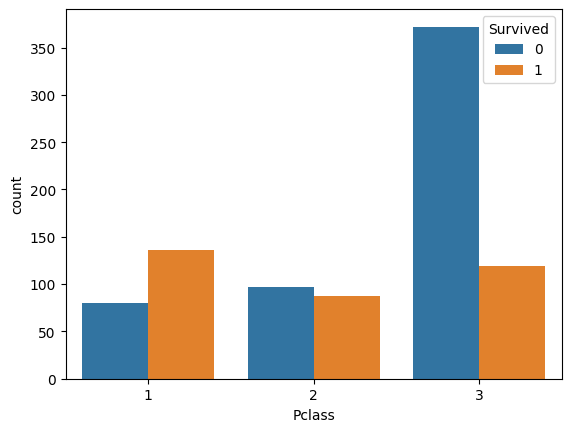

In [114]:
sns.countplot(x=df["Pclass"], hue=df["Survived"])

<Axes: xlabel='Sex', ylabel='count'>

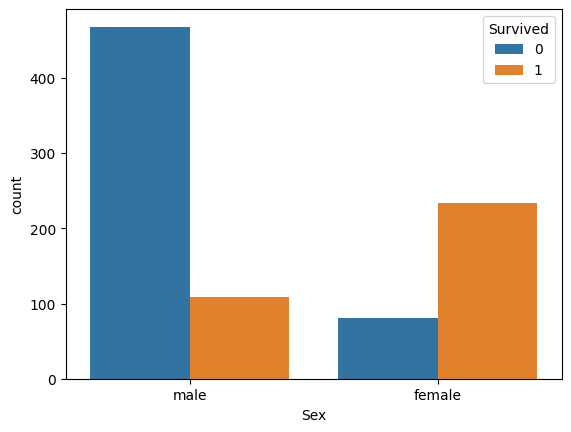

In [115]:
sns.countplot(x=df["Sex"], hue=df["Survived"])

<Axes: xlabel='Embarked', ylabel='count'>

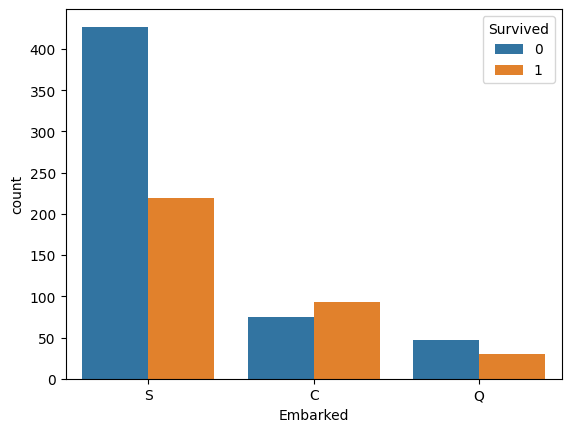

In [116]:
sns.countplot(x=df["Embarked"], hue=df["Survived"])

## Family Features
I created `FamilySize` and `IsAlone` because family size seems related to survival.


In [117]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [118]:
pd.crosstab(df["FamilySize"], df["Survived"])

Survived,0,1
FamilySize,,
1,374,163
2,72,89
3,43,59
4,8,21
5,12,3
6,19,3
7,8,4
8,6,0
11,7,0


In [119]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [120]:
df.drop(["SibSp", "Parch"], axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,HasCabin,Title,FamilySize,IsAlone
0,0,3,male,22.0,7.2500,S,0,Mr,2,0
1,1,1,female,38.0,71.2833,C,1,Mrs,2,0
2,1,3,female,26.0,7.9250,S,0,Miss,1,1
3,1,1,female,35.0,53.1000,S,1,Mrs,2,0
4,0,3,male,35.0,8.0500,S,0,Mr,1,1


## Fare Transformation
`Fare` was skewed, so I created `LogFare` and removed the original `Fare` column.


In [121]:
df["LogFare"] = np.log1p(df["Fare"])

df.drop("Fare", axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,Embarked,HasCabin,Title,FamilySize,IsAlone,LogFare
0,0,3,male,22.0,S,0,Mr,2,0,2.110213
1,1,1,female,38.0,C,1,Mrs,2,0,4.280593
2,1,3,female,26.0,S,0,Miss,1,1,2.188856
3,1,1,female,35.0,S,1,Mrs,2,0,3.990834
4,0,3,male,35.0,S,0,Mr,1,1,2.202765


## Encoding Categorical Columns
I converted categorical columns into numbers so the models can use them.


In [122]:
df['Sex']=df['Sex'].map({'male':0, 'female':1})
cat_columns = ["Embarked", "Title","Pclass"]
df = pd.get_dummies(df, columns=cat_columns, drop_first=True, dtype=int)
df.head()

,Survived,Sex,Age,HasCabin,FamilySize,IsAlone,LogFare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Pclass_2,Pclass_3
0,0,0,22.0,0,2,0,2.110213,0,1,0,1,0,0,0,1
1,1,1,38.0,1,2,0,4.280593,0,0,0,0,1,0,0,0
2,1,1,26.0,0,1,1,2.188856,0,1,1,0,0,0,0,1
3,1,1,35.0,1,2,0,3.990834,0,1,0,0,1,0,0,0
4,0,0,35.0,0,1,1,2.202765,0,1,0,1,0,0,0,1


## Correlation With Target
I checked the correlation of each feature with `Survived` to understand the strongest relationships.


In [123]:
corr_with_target = df.corr()["Survived"].sort_values(ascending=False)

corr_with_target

Survived      1.000000
Sex           0.543351
Title_Mrs     0.341994
Title_Miss    0.335636
LogFare       0.329862
HasCabin      0.316912
Pclass_2      0.093349
FamilySize    0.016639
Embarked_Q    0.003650
Title_Rare   -0.012054
Age          -0.059579
Embarked_S   -0.149683
IsAlone      -0.203367
Pclass_3     -0.322308
Title_Mr     -0.549199
Name: Survived, dtype: float64

## Train/Test Split
I split the data into training and testing sets, using stratify to keep the target distribution similar.


In [124]:
x=df.drop("Survived", axis=1)
y=df["Survived"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((712, 14), (712,), (179, 14), (179,))

## Logistic Regression
For Logistic Regression, I scaled the features first and then trained the model.


In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [126]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(x_train_scaled, y_train)

y_pred_log=log_model.predict(x_test_scaled)

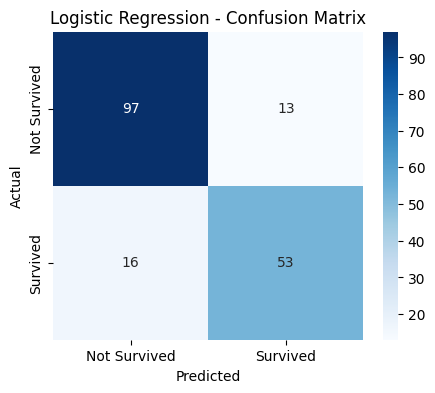

In [127]:
from sklearn.metrics import confusion_matrix, classification_report

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [128]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



## XGBoost Model
I trained XGBoost on the original features because tree-based models usually do not need scaling.


In [129]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

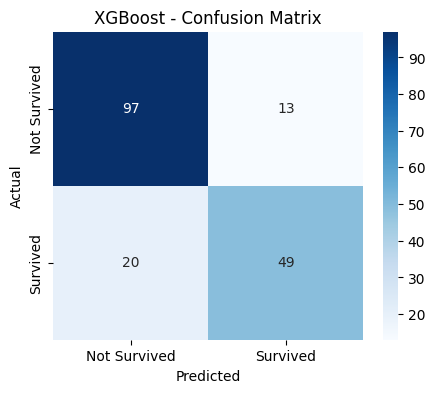

In [130]:
y_pred_xgb = xgb_model.predict(x_test)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [131]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



## Cross Validation
I used 5-fold cross validation to compare the models more fairly.


In [132]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

xgb_cv_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

In [133]:
from sklearn.model_selection import cross_val_score

log_scores = cross_val_score(
    log_pipeline,
    x,
    y,
    cv=cv,
    scoring="accuracy"
)

xgb_scores = cross_val_score(
    xgb_cv_model,
    x,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Logistic CV scores:", log_scores)
print("Logistic Mean Accuracy:", log_scores.mean())

print("\nXGBoost CV scores:", xgb_scores)
print("XGBoost Mean Accuracy:", xgb_scores.mean())

Logistic CV scores: [0.84357542 0.81460674 0.81460674 0.84269663 0.84831461]
Logistic Mean Accuracy: 0.8327600276191074

XGBoost CV scores: [0.8603352  0.84831461 0.81460674 0.83707865 0.80898876]
XGBoost Mean Accuracy: 0.833864791915134


## Model Comparison
I compared the mean accuracy and standard deviation for Logistic Regression and XGBoost.


In [134]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "CV Mean Accuracy": [log_scores.mean(), xgb_scores.mean()],
    "CV Std": [log_scores.std(), xgb_scores.std()]
})

comparison

,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.832760,0.014945
1,XGBoost,0.833865,0.019542


## Conclusion
Both models gave close results. Logistic Regression is a good baseline because it is simple and easy to understand. XGBoost can still be improved later using hyperparameter tuning.


In [135]:
import pickle

model_data = {
    "model": log_model,
    "scaler": scaler,
    "columns": x.columns.tolist()
}

import joblib

joblib.dump(model_data, "model.pkl")

['model.pkl']